# Correlation — Measuring Linear Relationships

Correlation quantifies the strength and direction of the relationship between two numerical variables. It is one of the most important tools for understanding which features are likely to be predictive.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = sns.load_dataset('titanic')
print("Shape:", df.shape)

Shape: (891, 15)


## Covariance — The Raw Measure

Covariance measures whether two variables move together:

$$\text{Cov}(X, Y) = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})$$

- **Positive** → both variables tend to move in the same direction
- **Negative** → they tend to move in opposite directions
- **Zero** → no linear relationship

**Problem**: the magnitude depends on the units and scale of each variable, making it hard to compare across pairs.

In [2]:
num_df = df[['age', 'fare', 'pclass', 'sibsp', 'parch']].dropna()
cov_matrix = num_df.cov().round(2)
print("Covariance matrix:")
print(cov_matrix)

Covariance matrix:
           age     fare  pclass  sibsp  parch
age     211.02    73.85   -4.50  -4.16  -2.34
fare     73.85  2800.41  -24.58   6.81   9.26
pclass   -4.50   -24.58    0.70   0.05   0.02
sibsp    -4.16     6.81    0.05   0.86   0.30
parch    -2.34     9.26    0.02   0.30   0.73


## Pearson Correlation Coefficient

Normalise covariance by the product of the two standard deviations:

$$r = \frac{\text{Cov}(X, Y)}{\sigma_X \cdot \sigma_Y}$$

**Properties**:
- Always in the range **[−1, +1]**
- `r = +1` → perfect positive linear relationship
- `r = −1` → perfect negative linear relationship
- `r = 0` → no linear relationship
- **Dimensionless** — directly comparable across different variable pairs

| |r| | Interpretation |
|---|---|
| 0.8 – 1.0 | Very strong |
| 0.6 – 0.8 | Strong |
| 0.4 – 0.6 | Moderate |
| 0.2 – 0.4 | Weak |
| 0.0 – 0.2 | Very weak / negligible |

In [3]:
corr_matrix = num_df.corr().round(3)
print("Pearson Correlation Matrix:")
print(corr_matrix)

Pearson Correlation Matrix:
          age   fare  pclass  sibsp  parch
age     1.000  0.096  -0.369 -0.308 -0.189
fare    0.096  1.000  -0.554  0.138  0.205
pclass -0.369 -0.554   1.000  0.067  0.026
sibsp  -0.308  0.138   0.067  1.000  0.384
parch  -0.189  0.205   0.026  0.384  1.000


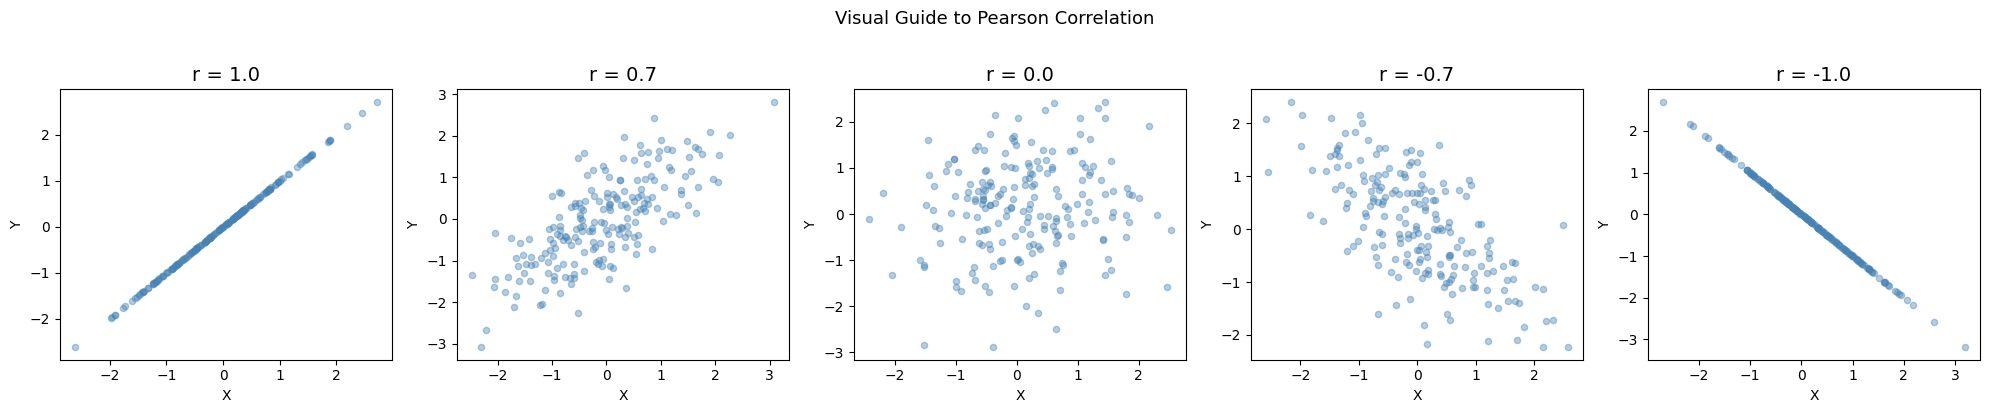

In [4]:
# Visualise five different correlation strengths
np.random.seed(42)
n = 200

def correlated_pair(r, n=200):
    x = np.random.randn(n)
    y = r * x + np.sqrt(1 - r**2) * np.random.randn(n)
    return x, y

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, r in zip(axes, [1.0, 0.7, 0.0, -0.7, -1.0]):
    x, y = correlated_pair(r)
    ax.scatter(x, y, alpha=0.4, s=20, color='steelblue')
    ax.set_title(f'r = {r:.1f}', fontsize=14)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

plt.suptitle('Visual Guide to Pearson Correlation', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## Correlation Heatmap

A heatmap shows the entire correlation matrix at once — much more efficient than scanning a table.

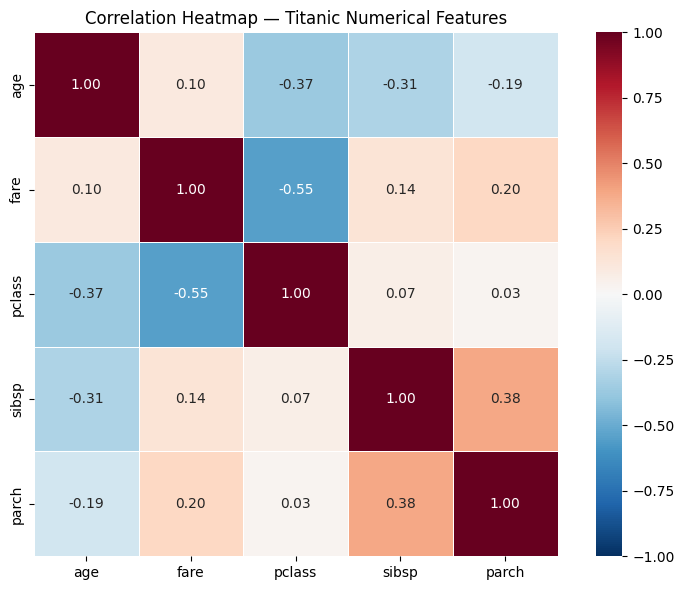

In [5]:
plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Heatmap — Titanic Numerical Features')
plt.tight_layout()
plt.show()

In [6]:
# Identify the strongest correlations
corr_pairs = (
    corr_matrix
    .unstack()
    .reset_index()
    .rename(columns={'level_0': 'Feature A', 'level_1': 'Feature B', 0: 'r'})
)
# Remove self-correlations and duplicate pairs
corr_pairs = corr_pairs[corr_pairs['Feature A'] < corr_pairs['Feature B']]
corr_pairs = corr_pairs.reindex(corr_pairs['r'].abs().sort_values(ascending=False).index)
print("Correlation pairs (strongest first):")
print(corr_pairs.to_string(index=False))

Correlation pairs (strongest first):
Feature A Feature B      r
     fare    pclass -0.554
    parch     sibsp  0.384
      age    pclass -0.369
      age     sibsp -0.308
     fare     parch  0.205
      age     parch -0.189
     fare     sibsp  0.138
      age      fare  0.096
   pclass     sibsp  0.067
    parch    pclass  0.026


## Scatter Plots for Key Pairs

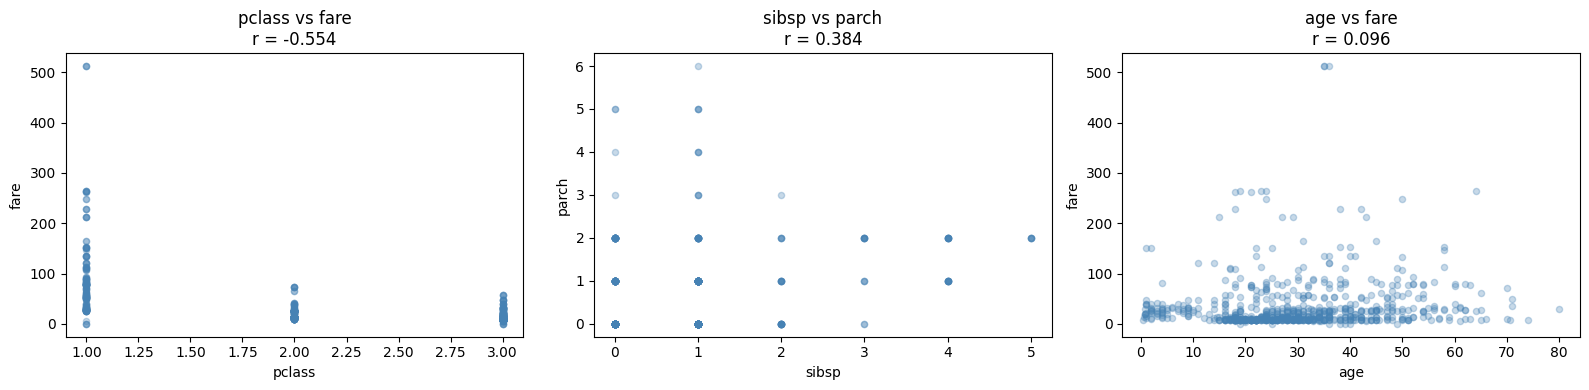

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

pairs = [('pclass', 'fare'), ('sibsp', 'parch'), ('age', 'fare')]
for ax, (x, y) in zip(axes, pairs):
    r = num_df[x].corr(num_df[y])
    ax.scatter(num_df[x], num_df[y], alpha=0.3, s=20, color='steelblue')
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}\nr = {r:.3f}')

plt.tight_layout()
plt.show()

## Important Caveats

**Correlation ≠ Causation**  
Two variables can be highly correlated because:
- One causes the other
- A third variable (confounder) drives both
- It is a spurious coincidence

**Pearson r only captures linear relationships**  
A variable can have a strong non-linear relationship yet show r ≈ 0.

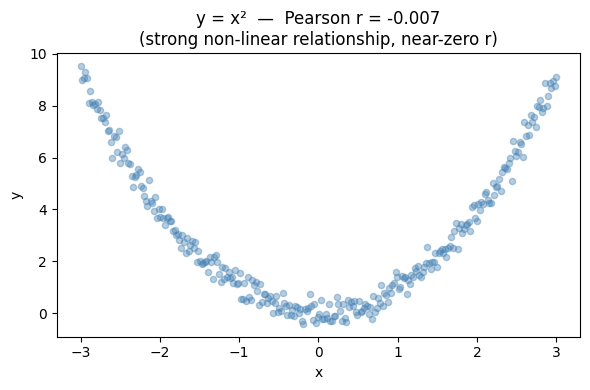

In [8]:
# Non-linear relationship with near-zero Pearson r
np.random.seed(0)
x = np.linspace(-3, 3, 300)
y = x**2 + np.random.randn(300) * 0.3

r = np.corrcoef(x, y)[0, 1]

plt.figure(figsize=(6, 4))
plt.scatter(x, y, alpha=0.4, s=20, color='steelblue')
plt.title(f'y = x²  —  Pearson r = {r:.3f}\n(strong non-linear relationship, near-zero r)')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()

## Key Takeaways

| Concept | Summary |
|---|---|
| Covariance | Direction only; scale-dependent |
| Pearson r | Normalised: −1 to +1; linear only |
| Heatmap | Best way to survey all pairs at once |
| High r | Strong linear relationship — not necessarily causal |
| r ≈ 0 | No *linear* relationship — non-linear may still exist |

Always pair heatmaps with scatter plots to verify the relationship is actually linear.